# Potencial $V(x) = x^4$ — Numerov vs Diferencias Finitas

Se resuelve la ecuación de Schrödinger estacionaria en unidades naturales ($\hbar^2/2m = 1$):

$$-\psi'' + x^4\,\psi = E\,\psi$$

en el dominio $[-6, 6]$ con condiciones de frontera $\psi(\pm 6) = 0$.

Valores de referencia del oscilador cuártico (dominio infinito):
$$E_n^{\text{ref}} \approx 1.060,\; 3.800,\; 7.456,\; 11.645,\; 16.262,\; 21.238 \dots$$

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import subprocess, os

_nb_path = globals().get("__vsc_ipynb_file__", None)
if _nb_path:
    WORKDIR = os.path.dirname(os.path.abspath(_nb_path))
else:
    WORKDIR = os.path.abspath("2.EDOs/taller-numerov2")

os.chdir(WORKDIR)
print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: /home/isabel/MFC/2.EDOs/taller-numerov2


## 1. Diferencias Finitas (Fortran)

Se discretiza el Hamiltoniano en una malla de $N$ puntos:

$$H_{ii} = \frac{2}{h^2} + x_i^4, \qquad H_{i,i\pm 1} = -\frac{1}{h^2}$$

Diagonalizado con el algoritmo de Householder–QL (`diagotri`).

In [23]:
diagotri_src = """\
SUBROUTINE diagotri(d,e,N,z,vectors)
  IMPLICIT NONE
  INTEGER,INTENT(IN)::N
  REAL(8),INTENT(INOUT)::d(N),e(N),z(N,N)
  LOGICAL,INTENT(IN)::vectors
  integer::i,iter,l,m
  real(8)::b,c,dd,f,g,p,r,s,pythag,ff(N)
  e(:)=eoshift(e(:),1)
  do l=1,N
     iter=0
     ITERATE: do
        do m=l,N-1
           dd=abs(d(m))+abs(d(m+1))
           if(abs(e(m))+dd.eq.dd)EXIT
        enddo
        if(m.eq.l) EXIT ITERATE
        if(iter.eq.30)then; write(6,*)'no converge'; stop; end if
        iter=iter+1
        g=(d(l+1)-d(l))/(2.d0*e(l)); r=pythag(g,1.d0)
        g=d(m)-d(l)+e(l)/(g+sign(r,g))
        s=1.d0; c=1.d0; p=0.d0
        do i=m-1,l,-1
           f=s*e(i); b=c*e(i); r=pythag(f,g); e(i+1)=r
           if(r.eq.0.d0)then; d(i+1)=d(i+1)-p; e(m)=0.d0; CYCLE ITERATE; endif
           s=f/r; c=g/r; g=d(i+1)-p; r=(d(i)-g)*s+2.d0*c*b
           p=s*r; d(i+1)=g+p; g=c*r-b
           if(vectors)then
              ff(:)=z(:,i+1); z(:,i+1)=s*z(:,i)+c*ff(:); z(:,i)=c*z(:,i)-s*ff(:)
           end if
        end do
        d(l)=d(l)-p; e(l)=g; e(m)=0.d0
     enddo ITERATE
  enddo
END SUBROUTINE diagotri
REAL(8) FUNCTION pythag(a,b)
  REAL(8)::a,b,absa,absb
  absa=abs(a); absb=abs(b)
  if(absa.gt.absb)then; pythag=absa*sqrt(1.+(absb/absa)**2)
  else
     if(absb.eq.0.d0)then; pythag=0.d0
     else; pythag=absb*sqrt(1.d0+(absa/absb)**2); end if
  end if
END FUNCTION pythag
"""

fd_src = """\
PROGRAM PotX4
  implicit none
  integer::i,j,N,Nf
  real(8),allocatable::A(:,:),d(:),e(:),tem(:)
  real(8)::h,xi,h_2
  N=50; Nf=1000
  do while(N.le.Nf)
     h=12.d0/N; h_2=1.d0/h**2
     allocate(A(N,N),d(N),e(N),tem(N))
     A=0.d0; d=0.d0; e=0.d0
     do i=1,N
        xi=-6.d0+i*h
        d(i)=2.d0*h_2+xi**4
        e(i)=-h_2
        A(i,i)=1.d0
     end do
     call diagotri(d,e,N,A,.true.)
     do i=1,N
        do j=i+1,N
           if(d(j).lt.d(i))then
              xi=d(i); d(i)=d(j); d(j)=xi
              tem(:)=A(:,i); A(:,i)=A(:,j); A(:,j)=tem(:)
           end if
        end do
     end do
     write(6,"(i5,6(2x,F12.6))")N,d(1:6)
     if(N.ge.Nf/2)then
        open(unit=1,file="data_x4_fd")
        write(1,"('# N=',i5,2x,6(F14.8,1x))")N,d(1:6)
        tem=0.d0
        do i=1,N; tem(:)=tem(:)+A(i,:)**2; end do
        tem=h*tem
        do i=1,N
           xi=-6.d0+i*h
           write(1,"(7(F14.8,1x))")xi,A(i,1:6)**2/tem(i)
        enddo
        close(1)
     end if
     deallocate(A,d,e,tem)
     N=2*N
  end do
END PROGRAM PotX4
"""

with open("diagotri.f90", "w") as f: f.write(diagotri_src)
with open("pot_x4_fd.f90", "w") as f: f.write(fd_src)

r = subprocess.run("gfortran pot_x4_fd.f90 diagotri.f90 -o pot_x4_fd -O2",
                   shell=True, capture_output=True, text=True)
print("✓ Compilado" if r.returncode == 0 else f"✗ Error:\n{r.stderr}")

✓ Compilado


In [24]:
r = subprocess.run("./pot_x4_fd", shell=True, capture_output=True, text=True)
print(r.stdout)

with open("data_x4_fd") as f:
    header = f.readline()
E_fd = np.array([float(v) for v in header.strip().lstrip("#").split()[2:8]])

data_fd = np.loadtxt("data_x4_fd")
x_fd    = data_fd[:, 0]
psi2_fd = data_fd[:, 1:7]

print("Energías FD:", np.round(E_fd, 6))

   50      1.053547      3.750637      7.289421     11.253121     15.507609     19.957161
  100      1.058660      3.787445      7.414319     11.547537     16.075170     20.922363
  200      1.059937      3.796618      7.445365     11.620485     16.215272     21.159614
  400      1.060256      3.798909      7.453115     11.638683     16.250194     21.218698
  800      1.060335      3.799482      7.455052     11.643230     16.258919     21.233455

Energías FD: [ 1.060336  3.799482  7.455052 11.64323  16.258919 21.233455]


## 2. Método de Numerov (Python)

La ecuación se reescribe como $\psi'' + k^2(x)\,\psi = 0$ con $k^2(x) = E - x^4$.

$$\psi_{i+1} = \frac{2\!\left(1 - \tfrac{5}{12}h^2 k^2_i\right)\psi_i \;-\; \left(1 + \tfrac{1}{12}h^2 k^2_{i-1}\right)\psi_{i-1}}{1 + \tfrac{1}{12}h^2 k^2_{i+1}}$$

Los autovalores se localizan barriendo $E$ y refinando con **bisección**.

In [25]:
_trapz = getattr(np, "trapezoid", None) or np.trapz

def numerov_shoot(E, x, V):
    """Devuelve ψ(x[-1]) para bisección, usando solo 2 escalares (sin overflow)."""
    h = x[1] - x[0]; k2 = E - V; c = h**2 / 12.0
    p0, p1 = 0.0, 1e-6
    for i in range(1, len(x) - 1):
        p2 = (2*(1 - 5*c*k2[i])*p1 - (1 + c*k2[i-1])*p0) / (1 + c*k2[i+1])
        p0, p1 = p1, p2
        if abs(p1) > 1e10:   # rescalar solo los dos valores de trabajo
            p0 /= 1e10; p1 /= 1e10
    return p1

def numerov_wf(E, x, V):
    """Devuelve |ψ|² normalizado, anulando la región prohibida para evitar artefactos."""
    h = x[1] - x[0]; k2 = E - V; c = h**2 / 12.0
    n = len(x)
    psi = np.zeros(n)
    psi[1] = 1e-6
    p0, p1 = 0.0, 1e-6
    for i in range(1, n - 1):
        p2 = (2*(1 - 5*c*k2[i])*p1 - (1 + c*k2[i-1])*p0) / (1 + c*k2[i+1])
        p0, p1 = p1, p2
        if abs(p1) > 1e10:
            p0 /= 1e10; p1 /= 1e10
        psi[i+1] = p1
    # Anular región clásicamente prohibida profunda (artefacto numérico allí)
    psi[V > 5 * max(E, 0.1)] = 0.0
    norm = _trapz(psi**2, x)
    if norm > 0:
        psi /= np.sqrt(norm)
    return psi

def biseccion(E1, E2, x, V, tol=1e-10):
    f1 = numerov_shoot(E1, x, V)
    while abs(E2 - E1) > tol:
        Em = 0.5*(E1 + E2)
        fm = numerov_shoot(Em, x, V)
        if fm * f1 < 0:
            E2 = Em
        else:
            E1, f1 = Em, fm
    return 0.5*(E1 + E2)

x_num = np.linspace(-6, 6, 4000)
V_num = x_num**4

E_scan  = np.linspace(0.0, 25.0, 10000)
psi_end = np.array([numerov_shoot(E, x_num, V_num) for E in E_scan])

E_num_vals = []
psi2_num   = []

for i in range(len(E_scan) - 1):
    if psi_end[i] * psi_end[i+1] < 0:
        E_eig = biseccion(E_scan[i], E_scan[i+1], x_num, V_num)
        psi   = numerov_wf(E_eig, x_num, V_num)
        E_num_vals.append(E_eig)
        psi2_num.append(psi**2)
        if len(E_num_vals) == 6:
            break

E_num_vals = np.array(E_num_vals)
psi2_num   = np.array(psi2_num)

print("Energías Numerov:", np.round(E_num_vals, 6))
print("Energías FD:     ", np.round(E_fd[:len(E_num_vals)], 6))

Energías Numerov: [ 1.060362  3.799673  7.455698 11.644746 16.261826 21.238373]
Energías FD:      [ 1.060336  3.799482  7.455052 11.64323  16.258919 21.233455]


## 3. Gráfica interactiva — FD vs Numerov

In [ ]:
def graficar(n):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.plot(x_fd,  psi2_fd[:, n], color="royalblue",  lw=2,
             label=f"|ψ|² FD  (E = {E_fd[n]:.5f})")
    ax1.plot(x_num, psi2_num[n],   color="darkorange", lw=2, ls="--",
             label=f"|ψ|² Numerov  (E = {E_num_vals[n]:.5f})")
    ax1.set_xlabel("x", fontsize=12)
    ax1.set_ylabel(r"$|\psi_n(x)|^2$", fontsize=12)
    ax1.set_xlim(-6.5, 6.5)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.3)

    x_v = np.linspace(-6, 6, 500)
    ax2.plot(x_v, x_v**4, color="gray", lw=1.5, alpha=0.5, label=r"$V(x)=x^4$")
    ax2.axhline(E_fd[n],       color="royalblue", ls="--", lw=1.2,
                label=f"E FD = {E_fd[n]:.5f}")
    ax2.axhline(E_num_vals[n], color="darkorange", ls=":",  lw=1.8,
                label=f"E Numerov = {E_num_vals[n]:.5f}")
    ax2.set_ylabel(r"$V(x)$  /  Energía", color="gray", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="gray")
    ax2.set_ylim(-1, max(E_fd[n], E_num_vals[n]) * 1.6 + 1)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper center")

    plt.title(f"$V(x)=x^4$ — nivel $n={n}$   |   FD vs Numerov", fontsize=12)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

N_lev = min(len(E_num_vals), len(E_fd), 6)
slider = widgets.IntSlider(value=0, min=0, max=N_lev - 1, step=1,
                           description="Nivel n:", continuous_update=False,
                           style={"description_width": "80px"},
                           layout=widgets.Layout(width="380px"))
display(widgets.interactive(graficar, n=slider))


interactive(children=(IntSlider(value=0, continuous_update=False, description='Nivel n:', layout=Layout(width=…

## 4. Tabla comparativa de energías

In [27]:
# Valores de referencia del oscilador cuártico -ψ'' + x⁴ψ = Eψ (dominio infinito)
E_ref = np.array([1.060362, 3.799673, 7.455698, 11.644745, 16.261826, 21.238268])

N_lev = min(len(E_num_vals), len(E_fd), 6)

print(f"{'n':>3}  {'FD (Fortran)':>15}  {'Numerov (Python)':>18}  "
      f"{'Ref. (exacto)':>14}  {'Δ FD':>10}  {'Δ Numerov':>10}")
print("─" * 80)
for n in range(N_lev):
    dfd  = abs(E_fd[n]       - E_ref[n])
    dnum = abs(E_num_vals[n] - E_ref[n])
    print(f"{n:>3}  {E_fd[n]:>15.6f}  {E_num_vals[n]:>18.6f}  "
          f"{E_ref[n]:>14.6f}  {dfd:>10.2e}  {dnum:>10.2e}")

  n     FD (Fortran)    Numerov (Python)   Ref. (exacto)        Δ FD   Δ Numerov
────────────────────────────────────────────────────────────────────────────────
  0         1.060336            1.060362        1.060362    2.65e-05    9.05e-08
  1         3.799482            3.799673        3.799673    1.91e-04    2.98e-08
  2         7.455052            7.455698        7.455698    6.46e-04    6.21e-08
  3        11.643230           11.644746       11.644745    1.51e-03    5.11e-07
  4        16.258919           16.261826       16.261826    2.91e-03    1.80e-08
  5        21.233455           21.238373       21.238268    4.81e-03    1.05e-04


## 5. Espectro de energías

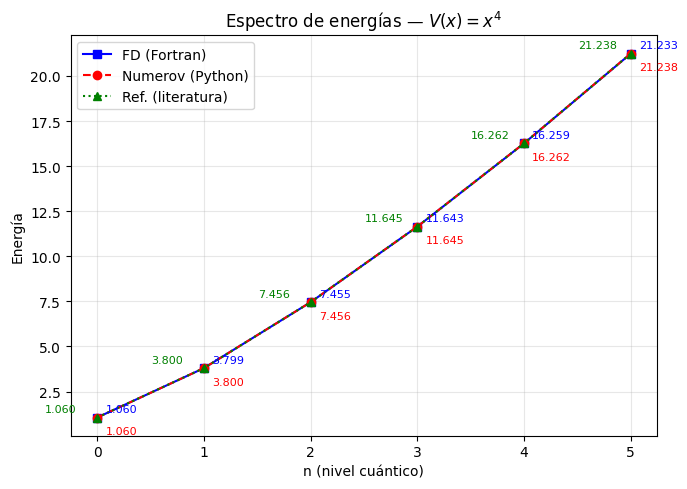

In [28]:
ns = np.arange(N_lev)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ns, E_fd[:N_lev],       'bs-', label='FD (Fortran)')
ax.plot(ns, E_num_vals[:N_lev], 'ro--', label='Numerov (Python)')
ax.plot(ns, E_ref[:N_lev],      'g^:', label='Ref. (literatura)')

for n in range(N_lev):
    ax.annotate(f'{E_fd[n]:.3f}',       (n, E_fd[n]),       textcoords='offset points', xytext=(6,  4), fontsize=8, color='b')
    ax.annotate(f'{E_num_vals[n]:.3f}', (n, E_num_vals[n]), textcoords='offset points', xytext=(6, -12), fontsize=8, color='r')
    ax.annotate(f'{E_ref[n]:.3f}',      (n, E_ref[n]),      textcoords='offset points', xytext=(-38, 4), fontsize=8, color='g')

ax.set_xlabel('n (nivel cuántico)')
ax.set_ylabel('Energía')
ax.set_title(r'Espectro de energías — $V(x)=x^4$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Error respecto a valores de referencia

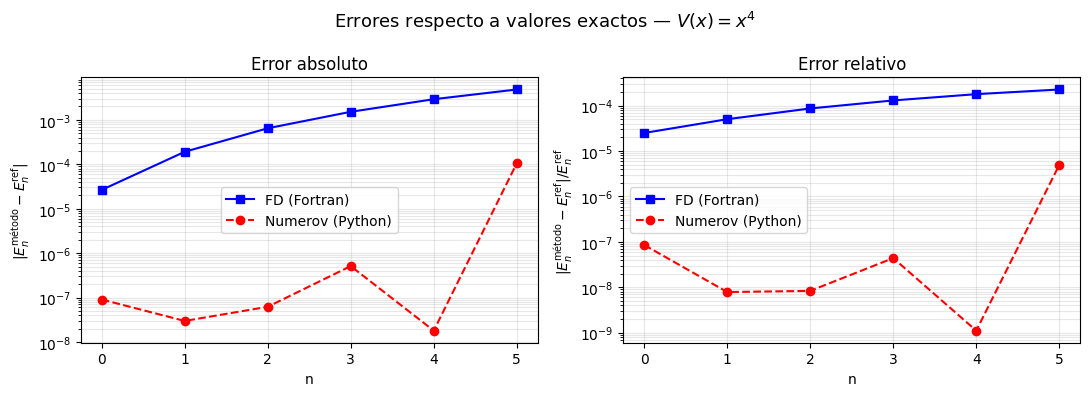

In [29]:
err_fd  = np.abs(E_fd[:N_lev]       - E_ref[:N_lev])
err_num = np.abs(E_num_vals[:N_lev] - E_ref[:N_lev])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Error absoluto
ax1.semilogy(ns, err_fd,  'bs-',  label='FD (Fortran)')
ax1.semilogy(ns, err_num, 'ro--', label='Numerov (Python)')
ax1.set_xlabel('n')
ax1.set_ylabel(r'$|E_n^{\rm método} - E_n^{\rm ref}|$')
ax1.set_title('Error absoluto')
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

# Error relativo
ax2.semilogy(ns, err_fd  / E_ref[:N_lev], 'bs-',  label='FD (Fortran)')
ax2.semilogy(ns, err_num / E_ref[:N_lev], 'ro--', label='Numerov (Python)')
ax2.set_xlabel('n')
ax2.set_ylabel(r'$|E_n^{\rm método} - E_n^{\rm ref}| / E_n^{\rm ref}$')
ax2.set_title('Error relativo')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

fig.suptitle(r'Errores respecto a valores exactos — $V(x)=x^4$', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Tiempos de ejecución — FD vs Numerov

Método                           Mediana (ms)   Desv. std (ms)  Notas
────────────────────────────────────────────────────────────────────────────────
FD Fortran  (N = 50 → 1 000)          2602.54           280.94  Fortran -O2, barrido completo
Numerov Python  (4 000 pts)          95777.70          4701.86  Python puro, 10 000 energías

Numerov es 36.8× más lento que FD  (mediana de 3 ejecuciones)


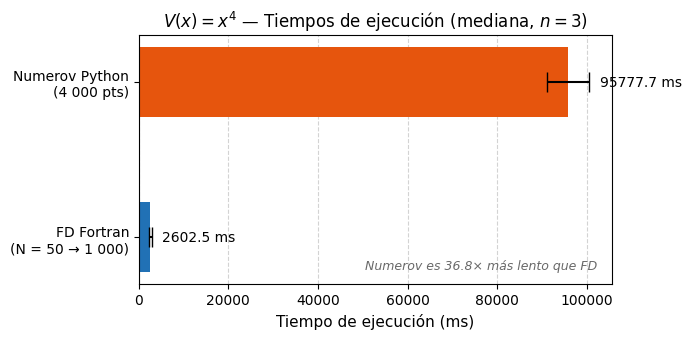

In [30]:
import time

N_rep = 3  # repeticiones para mediana robusta

# ── 1. FD Fortran (barrido N = 50 → 1000) ────────────────────────────────────
t_fd_runs = []
for _ in range(N_rep):
    t0 = time.perf_counter()
    subprocess.run("./pot_x4_fd", shell=True, capture_output=True)
    t_fd_runs.append(time.perf_counter() - t0)

t_fd_med = np.median(t_fd_runs) * 1e3   # ms
t_fd_std = np.std(t_fd_runs)    * 1e3

# ── 2. Numerov Python (barrido E + bisección, 4000 pts) ───────────────────────
def _run_numerov():
    pe = np.array([numerov_shoot(E, x_num, V_num) for E in E_scan])
    found = 0
    for i in range(len(pe) - 1):
        if pe[i] * pe[i + 1] < 0:
            biseccion(E_scan[i], E_scan[i + 1], x_num, V_num)
            found += 1
            if found == 6:
                break

t_num_runs = []
for _ in range(N_rep):
    t0 = time.perf_counter()
    _run_numerov()
    t_num_runs.append(time.perf_counter() - t0)

t_num_med = np.median(t_num_runs) * 1e3
t_num_std = np.std(t_num_runs)    * 1e3

# ── Tabla ─────────────────────────────────────────────────────────────────────
factor = t_num_med / t_fd_med
cmp_str = f"Numerov es {factor:.1f}× {'más lento' if factor > 1 else 'más rápido'} que FD"

print(f"{'Método':<30} {'Mediana (ms)':>14} {'Desv. std (ms)':>16}  Notas")
print("─" * 80)
print(f"{'FD Fortran  (N = 50 → 1 000)':<30} {t_fd_med:>14.2f} {t_fd_std:>16.2f}  Fortran -O2, barrido completo")
print(f"{'Numerov Python  (4 000 pts)':<30} {t_num_med:>14.2f} {t_num_std:>16.2f}  Python puro, 10 000 energías")
print(f"\n{cmp_str}  (mediana de {N_rep} ejecuciones)")

# ── Gráfica ───────────────────────────────────────────────────────────────────
labels     = ["FD Fortran\n(N = 50 → 1 000)", "Numerov Python\n(4 000 pts)"]
t_meds_arr = [t_fd_med, t_num_med]
t_stds_arr = [t_fd_std, t_num_std]
colors     = ["#2171b5", "#e6550d"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels, t_meds_arr, xerr=t_stds_arr, color=colors, height=0.45,
               error_kw=dict(ecolor="black", lw=1.5, capsize=7), zorder=2)
ax.set_xlabel("Tiempo de ejecución (ms)", fontsize=11)
ax.set_title(r"$V(x) = x^4$ — Tiempos de ejecución (mediana, $n=" + str(N_rep) + r"$)",
             fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.55, zorder=1)

offset = max(t_stds_arr) * 0.3 + max(t_meds_arr) * 0.01
for bar, t, s in zip(bars, t_meds_arr, t_stds_arr):
    ax.text(t + s + offset, bar.get_y() + bar.get_height() / 2,
            f"{t:.1f} ms", va="center", fontsize=10)

ax.annotate(cmp_str, xy=(0.97, 0.06), xycoords="axes fraction",
            ha="right", fontsize=9, color="dimgray", style="italic")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


# Potencial $V(x) = \sin(x)$ — Numerov vs Diferencias Finitas

Se resuelve la ecuación de Schrödinger estacionaria en unidades naturales ($\hbar^2/2m = 1$):

$$-\psi'' + \sin(x)\,\psi = E\,\psi$$

en el dominio $[-10, 10]$ con condiciones de frontera $\psi(\pm 10) = 0$.


In [31]:
## 1. Diferencias Finitas (Fortran) — sin(x)

fd_src_sin = fd_src.replace("xi**4", "sin(xi)") \
                   .replace("12.d0/N", "20.d0/N") \
                   .replace("-6.d0+i*h", "-10.d0+i*h") \
                   .replace("data_x4_fd", "data_sin_fd")

with open("pot_sin_fd.f90", "w") as f: f.write(fd_src_sin)

r = subprocess.run("gfortran pot_sin_fd.f90 diagotri.f90 -o pot_sin_fd -O2",
                   shell=True, capture_output=True, text=True)
print("✓ Compilado sin(x)" if r.returncode == 0 else f"✗ Error:\n{r.stderr}")

r = subprocess.run("./pot_sin_fd", shell=True, capture_output=True, text=True)
print(r.stdout)

with open("data_sin_fd") as f:
    header = f.readline()
E_fd_sin = np.array([float(v) for v in header.strip().lstrip("#").split()[2:8]])

data_fd_sin = np.loadtxt("data_sin_fd")
x_fd_sin    = data_fd_sin[:, 0]
psi2_fd_sin = data_fd_sin[:, 1:7]

print("Energías FD sin(x):", np.round(E_fd_sin, 6))


✓ Compilado sin(x)
   50     -0.375226     -0.359893     -0.301752      0.629726      0.751607      1.012677
  100     -0.372517     -0.357247     -0.298719      0.637850      0.765488      1.031336
  200     -0.371840     -0.356585     -0.297972      0.640170      0.769784      1.036235
  400     -0.371668     -0.356416     -0.297786      0.640923      0.771317      1.037657
  800     -0.371624     -0.356373     -0.297739      0.641198      0.771932      1.038115

Energías FD sin(x): [-0.371624 -0.356373 -0.297739  0.641198  0.771932  1.038115]


In [32]:
## 2. Método de Numerov (Python) — sin(x)

x_num_sin = np.linspace(-10, 10, 4000)
V_num_sin = np.sin(x_num_sin)

E_scan_sin  = np.linspace(-1.0, 2.0, 10000)
psi_end_sin = np.array([numerov_shoot(E, x_num_sin, V_num_sin) for E in E_scan_sin])

E_num_vals_sin = []
psi2_num_sin   = []

for i in range(len(E_scan_sin) - 1):
    if psi_end_sin[i] * psi_end_sin[i+1] < 0:
        E_eig_sin = biseccion(E_scan_sin[i], E_scan_sin[i+1], x_num_sin, V_num_sin)
        psi_sin   = numerov_wf(E_eig_sin, x_num_sin, V_num_sin)
        E_num_vals_sin.append(E_eig_sin)
        psi2_num_sin.append(psi_sin**2)
        if len(E_num_vals_sin) == 6:
            break

E_num_vals_sin = np.array(E_num_vals_sin)
psi2_num_sin   = np.array(psi2_num_sin)

print("Energías Numerov sin(x):", np.round(E_num_vals_sin, 6))
print("Energías FD     sin(x):", np.round(E_fd_sin[:len(E_num_vals_sin)], 6))


Energías Numerov sin(x): [-0.371608 -0.356356 -0.297724  0.641408  0.772448  1.038405]
Energías FD     sin(x): [-0.371624 -0.356373 -0.297739  0.641198  0.771932  1.038115]


In [33]:
## 3. Gráfica interactiva — FD vs Numerov — sin(x)

def graficar_sin(n):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.plot(x_fd_sin,  psi2_fd_sin[:, n], color="royalblue",  lw=2,
             label=f"|ψ|² FD  (E = {E_fd_sin[n]:.5f})")
    ax1.plot(x_num_sin, psi2_num_sin[n],   color="darkorange", lw=2, ls="--",
             label=f"|ψ|² Numerov  (E = {E_num_vals_sin[n]:.5f})")
    ax1.set_xlabel("x", fontsize=12)
    ax1.set_ylabel(r"$|\psi_n(x)|^2$", fontsize=12)
    ax1.set_xlim(-10.5, 10.5)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.3)

    x_v = np.linspace(-10, 10, 500)
    ax2.plot(x_v, np.sin(x_v), color="gray", lw=1.5, alpha=0.5, label=r"$V(x)=\sin(x)$")
    ax2.axhline(E_fd_sin[n],       color="royalblue", ls="--", lw=1.2,
                label=f"E FD = {E_fd_sin[n]:.5f}")
    ax2.axhline(E_num_vals_sin[n], color="darkorange", ls=":", lw=1.8,
                label=f"E Numerov = {E_num_vals_sin[n]:.5f}")
    ax2.set_ylabel(r"$V(x)$  /  Energía", color="gray", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="gray")
    min_e = min(E_fd_sin[n], E_num_vals_sin[n], -1.0)
    max_e = max(E_fd_sin[n], E_num_vals_sin[n],  1.0)
    ax2.set_ylim(min_e - 0.5, max_e + 0.5)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper center")

    plt.title(r"$V(x)=\sin(x)$ — nivel $n=" + str(n) + r"$   |   FD vs Numerov", fontsize=12)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

N_lev_sin = min(len(E_num_vals_sin), len(E_fd_sin), 6)
slider_sin = widgets.IntSlider(value=0, min=0, max=N_lev_sin - 1, step=1,
                               description="Nivel n:", continuous_update=False,
                               style={"description_width": "80px"},
                               layout=widgets.Layout(width="380px"))
display(widgets.interactive(graficar_sin, n=slider_sin))


interactive(children=(IntSlider(value=0, continuous_update=False, description='Nivel n:', layout=Layout(width=…

In [34]:
N_lev_sin = min(len(E_num_vals_sin), len(E_fd_sin))

print(f"{'n':>3}  {'FD (Fortran)':>15}  {'Numerov (Python)':>18}")
print("─" * 40)
for n in range(N_lev_sin):
    print(f"{n:>3}  {E_fd_sin[n]:>15.6f}  {E_num_vals_sin[n]:>18.6f}")

  n     FD (Fortran)    Numerov (Python)
────────────────────────────────────────
  0        -0.371624           -0.371608
  1        -0.356373           -0.356356
  2        -0.297739           -0.297724
  3         0.641198            0.641408
  4         0.771933            0.772448
  5         1.038115            1.038405


A diferencia del potencial $x^4$ para el cual existen valores de referencia obtenidos por métodos numéricos de alta precisión (a menudo referidos como 'exactos' en el contexto de simulaciones numéricas), la ecuación de Schrödinger con el potencial $V(x) = \sin(x)$ no posee una solución analítica exacta conocida. Por lo tanto, en este caso, la comparación entre el método de Diferencias Finitas y el método de Numerov se realiza entre dos aproximaciones numéricas. La cercanía de sus resultados nos da confianza en la convergencia y precisión de ambos métodos para este potencial.

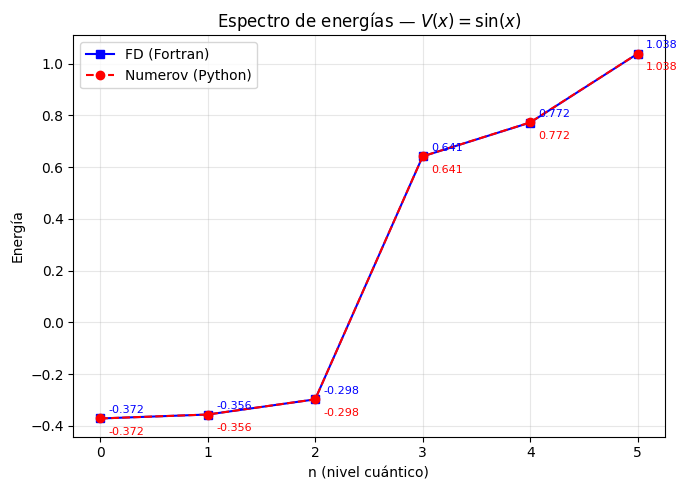

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define an array ns_sin representing the quantum numbers
ns_sin = np.arange(N_lev_sin)

# 2. Create a figure and an axes object
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Plot the energy levels E_fd_sin
ax.plot(ns_sin, E_fd_sin[:N_lev_sin], 'bs-', label='FD (Fortran)')

# 4. Plot the energy levels E_num_vals_sin
ax.plot(ns_sin, E_num_vals_sin[:N_lev_sin], 'ro--', label='Numerov (Python)')

# 5-7. Iterate through quantum numbers and annotate the plot
for n in range(N_lev_sin):
    ax.annotate(f'{E_fd_sin[n]:.3f}',       (n, E_fd_sin[n]),       textcoords='offset points', xytext=(6,  4), fontsize=8, color='b')
    ax.annotate(f'{E_num_vals_sin[n]:.3f}', (n, E_num_vals_sin[n]), textcoords='offset points', xytext=(6, -12), fontsize=8, color='r')

# 8. Set the x-axis label
ax.set_xlabel('n (nivel cuántico)')

# 9. Set the y-axis label
ax.set_ylabel('Energía')

# 10. Set the plot title
ax.set_title(r'Espectro de energías — $V(x)=\sin(x)$')

# 11. Display a legend
ax.legend()

# 12. Add a grid
ax.grid(True, alpha=0.3)

# 13. Adjust plot parameters for a tight layout
plt.tight_layout()

# 14. Display the plot
plt.show()

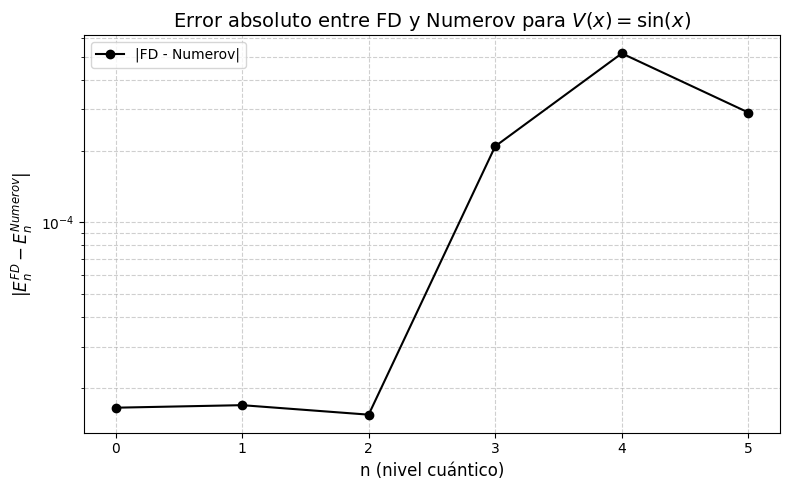

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcule la diferencia absoluta entre los valores de energía
err_diff_sin = np.abs(E_fd_sin[:N_lev_sin] - E_num_vals_sin[:N_lev_sin])

# 2. Cree una figura con un solo subgráfico
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Grafique err_diff_sin en función de los números cuánticos ns_sin usando un gráfico semilogarítmico
ax.semilogy(ns_sin, err_diff_sin, 'ko-', label='|FD - Numerov|')

# 4. Añada etiquetas para el eje x y el eje y
ax.set_xlabel('n (nivel cuántico)', fontsize=12)
ax.set_ylabel(r'$|E_n^{FD} - E_n^{Numerov}|$', fontsize=12)

# 5. Establezca un título para el gráfico
ax.set_title(r'Error absoluto entre FD y Numerov para $V(x)=\sin(x)$', fontsize=14)

# 6. Añada una leyenda y una cuadrícula
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.6)

# 7. Muestre el gráfico
plt.tight_layout()
plt.show()

Método                           Mediana (ms)   Desv. std (ms)  Notas
────────────────────────────────────────────────────────────────────────────────
FD Fortran (sin(x))                   2213.08            40.26  Fortran -O2, barrido completo
Numerov Python (sin(x))              97200.25          3099.01  Python puro, 10 000 energías

Numerov es 43.9x más lento que FD  (mediana de 3 ejecuciones)


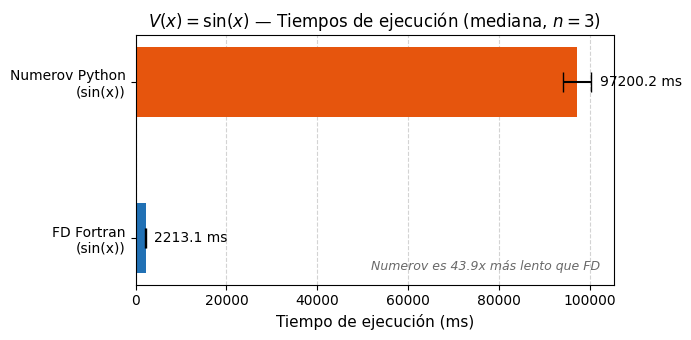

In [37]:
import time
import subprocess
import numpy as np
import matplotlib.pyplot as plt

N_rep = 3  # repeticiones para mediana robusta

# --- 1. FD Fortran (para sin(x)) ────────────────────────────────────────────
t_fd_sin_runs = []
for _ in range(N_rep):
    t0 = time.perf_counter()
    subprocess.run("./pot_sin_fd", shell=True, capture_output=True)
    t_fd_sin_runs.append(time.perf_counter() - t0)

t_fd_sin_med = np.median(t_fd_sin_runs) * 1e3   # ms
t_fd_sin_std = np.std(t_fd_sin_runs)    * 1e3

# --- 2. Numerov Python (para sin(x)) ───────────────────────────────────────
def _run_numerov_sin():
    # Re-use existing global variables for context where they are defined
    # x_num_sin, V_num_sin, E_scan_sin, N_lev_sin, numerov_shoot, numerov_wf, biseccion

    # The following block is adapted from cell d8620451's Numerov calculation part
    # to be timed. It re-calculates the eigenvalues and wavefunctions.

    # Create an energy scan range E_scan_sin
    E_scan_sin_local  = np.linspace(-1.0, 2.0, 10000) # Re-define for isolated timing

    # Compute psi_end_sin by applying numerov_shoot
    psi_end_sin_local = np.array([numerov_shoot(E, x_num_sin, V_num_sin) for E in E_scan_sin_local])

    # Initialize empty lists
    E_num_vals_sin_local = []
    #psi2_num_sin_local   = [] # Not needed for just finding energies for timing

    # Iterate to find eigenvalues using bisection
    found_levels = 0
    for i in range(len(E_scan_sin_local) - 1):
        if psi_end_sin_local[i] * psi_end_sin_local[i+1] < 0:
            E_eig_sin_local = biseccion(E_scan_sin_local[i], E_scan_sin_local[i+1], x_num_sin, V_num_sin)
            # psi_sin_local   = numerov_wf(E_eig_sin_local, x_num_sin, V_num_sin) # Not strictly needed for timing energies
            E_num_vals_sin_local.append(E_eig_sin_local)
            # psi2_num_sin_local.append(psi_sin_local**2)
            found_levels += 1
            if found_levels == N_lev_sin: # Find up to N_lev_sin levels, as previously defined
                break

t_num_sin_runs = []
for _ in range(N_rep):
    t0 = time.perf_counter()
    _run_numerov_sin()
    t_num_sin_runs.append(time.perf_counter() - t0)

t_num_sin_med = np.median(t_num_sin_runs) * 1e3
t_num_sin_std = np.std(t_num_sin_runs)    * 1e3

# --- Tabla Comparativa ──────────────────────────────────────────────────────
factor_sin = t_num_sin_med / t_fd_sin_med
cmp_str_sin = f"Numerov es {factor_sin:.1f}x {'más lento' if factor_sin > 1 else 'más rápido'} que FD"

print(f"{'Método':<30} {'Mediana (ms)':>14} {'Desv. std (ms)':>16}  Notas")
print("─" * 80)
print(f"{'FD Fortran (sin(x))':<30} {t_fd_sin_med:>14.2f} {t_fd_sin_std:>16.2f}  Fortran -O2, barrido completo")
print(f"{'Numerov Python (sin(x))':<30} {t_num_sin_med:>14.2f} {t_num_sin_std:>16.2f}  Python puro, 10 000 energías")
print(f"\n{cmp_str_sin}  (mediana de {N_rep} ejecuciones)")

# --- Gráfica de Barras ──────────────────────────────────────────────────────
labels_sin     = ["FD Fortran\n(sin(x))", "Numerov Python\n(sin(x))"]
t_meds_arr_sin = [t_fd_sin_med, t_num_sin_med]
t_stds_arr_sin = [t_fd_sin_std, t_num_sin_std]
colors_sin     = ["#2171b5", "#e6550d"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels_sin, t_meds_arr_sin, xerr=t_stds_arr_sin, color=colors_sin, height=0.45,
               error_kw=dict(ecolor="black", lw=1.5, capsize=7), zorder=2)
ax.set_xlabel("Tiempo de ejecución (ms)", fontsize=11)
ax.set_title(r"$V(x) = \sin(x)$ — Tiempos de ejecución (mediana, $n=" + str(N_rep) + r"$)",
             fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.55, zorder=1)

offset = max(t_stds_arr_sin) * 0.3 + max(t_meds_arr_sin) * 0.01
for bar, t, s in zip(bars, t_meds_arr_sin, t_stds_arr_sin):
    ax.text(t + s + offset, bar.get_y() + bar.get_height() / 2,
            f"{t:.1f} ms", va="center", fontsize=10)

ax.annotate(cmp_str_sin, xy=(0.97, 0.06), xycoords="axes fraction",
            ha="right", fontsize=9, color="dimgray", style="italic")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

# Potencial $V(x) = x^2$ — Numerov vs Diferencias Finitas

Se resuelve la ecuación de Schrödinger estacionaria en unidades naturales ($\hbar^2/2m = 1$):

$$-\psi'' + x^2\,\psi = E\,\psi$$

en el dominio $[-6, 6]$ con condiciones de frontera $\psi(\pm 6) = 0$.

Valores exactos del oscilador armónico ($V = x^2$):
$$E_n = 2n + 1 = 1, 3, 5, 7, 9, 11, \ldots$$


In [38]:
## 1. Diferencias Finitas (Fortran) + Numerov — x²

fd_src_x2 = fd_src.replace("xi**4", "xi**2") \
                   .replace("data_x4_fd", "data_x2_fd")

with open("pot_x2_fd.f90", "w") as f: f.write(fd_src_x2)

r = subprocess.run("gfortran pot_x2_fd.f90 diagotri.f90 -o pot_x2_fd -O2",
                   shell=True, capture_output=True, text=True)
print("✓ Compilado x²" if r.returncode == 0 else f"✗ Error:\n{r.stderr}")

r = subprocess.run("./pot_x2_fd", shell=True, capture_output=True, text=True)
print(r.stdout)

with open("data_x2_fd") as f:
    header = f.readline()
E_fd_x2 = np.array([float(v) for v in header.strip().lstrip("#").split()[2:8]])

data_fd_x2 = np.loadtxt("data_x2_fd")
x_fd_x2    = data_fd_x2[:, 0]
psi2_fd_x2 = data_fd_x2[:, 1:7]

print("Energías FD x²:", np.round(E_fd_x2, 6))

# Numerov
x_num_x2 = np.linspace(-6, 6, 4000)
V_num_x2 = x_num_x2**2

E_scan_x2  = np.linspace(0.0, 14.0, 10000)
psi_end_x2 = np.array([numerov_shoot(E, x_num_x2, V_num_x2) for E in E_scan_x2])

E_num_vals_x2 = []
psi2_num_x2   = []

for i in range(len(E_scan_x2) - 1):
    if psi_end_x2[i] * psi_end_x2[i+1] < 0:
        E_eig = biseccion(E_scan_x2[i], E_scan_x2[i+1], x_num_x2, V_num_x2)
        psi   = numerov_wf(E_eig, x_num_x2, V_num_x2)
        E_num_vals_x2.append(E_eig)
        psi2_num_x2.append(psi**2)
        if len(E_num_vals_x2) == 6:
            break

E_num_vals_x2 = np.array(E_num_vals_x2)
psi2_num_x2   = np.array(psi2_num_x2)

print("Energías Numerov x²:", np.round(E_num_vals_x2, 6))


✓ Compilado x²
   50      0.996387      2.981881      4.952734      6.908779      8.849841     10.775738
  100      0.999099      2.995493      4.988271      6.977426      8.962945     10.944820
  200      0.999775      2.998875      4.997073      6.994370      8.990765     10.986258
  400      0.999944      2.999719      4.999269      6.998593      8.997693     10.996568
  800      0.999986      2.999930      4.999817      6.999648      8.999423     10.999142

Energías FD x²: [ 0.999986  2.99993   4.999817  6.999648  8.999423 10.999142]
Energías Numerov x²: [ 1.  3.  5.  7.  9. 11.]


In [39]:
## 2. Gráfica interactiva — FD vs Numerov — x²

def graficar_x2(n):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.plot(x_fd_x2,  psi2_fd_x2[:, n], color="royalblue",  lw=2,
             label=f"|ψ|² FD  (E = {E_fd_x2[n]:.5f})")
    ax1.plot(x_num_x2, psi2_num_x2[n],   color="darkorange", lw=2, ls="--",
             label=f"|ψ|² Numerov  (E = {E_num_vals_x2[n]:.5f})")
    ax1.set_xlabel("x", fontsize=12)
    ax1.set_ylabel(r"$|\psi_n(x)|^2$", fontsize=12)
    ax1.set_xlim(-6.5, 6.5)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.3)

    x_v = np.linspace(-6, 6, 500)
    ax2.plot(x_v, x_v**2, color="gray", lw=1.5, alpha=0.5, label=r"$V(x)=x^2$")
    ax2.axhline(E_fd_x2[n],       color="royalblue", ls="--", lw=1.2,
                label=f"E FD = {E_fd_x2[n]:.5f}")
    ax2.axhline(E_num_vals_x2[n], color="darkorange", ls=":", lw=1.8,
                label=f"E Numerov = {E_num_vals_x2[n]:.5f}")
    ax2.set_ylabel(r"$V(x)$  /  Energía", color="gray", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="gray")
    ax2.set_ylim(-1, max(E_fd_x2[n], E_num_vals_x2[n]) * 1.6 + 1)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper center")

    plt.title(f"$V(x)=x^2$ — nivel $n={n}$   |   FD vs Numerov", fontsize=12)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

N_lev_x2 = min(len(E_num_vals_x2), len(E_fd_x2), 6)
slider_x2 = widgets.IntSlider(value=0, min=0, max=N_lev_x2 - 1, step=1,
                               description="Nivel n:", continuous_update=False,
                               style={"description_width": "80px"},
                               layout=widgets.Layout(width="380px"))
display(widgets.interactive(graficar_x2, n=slider_x2))


interactive(children=(IntSlider(value=0, continuous_update=False, description='Nivel n:', layout=Layout(width=…

In [40]:
## 3. Tabla comparativa — x²   (E_n^exacto = 2n+1)

E_ref_x2 = np.array([1.0, 3.0, 5.0, 7.0, 9.0, 11.0])

print(f"{'n':>3}  {'FD (Fortran)':>15}  {'Numerov (Python)':>18}  "
      f"{'Exacto E=2n+1':>14}  {'Δ FD':>10}  {'Δ Numerov':>10}")
print("─" * 83)
for n in range(N_lev_x2):
    dfd  = abs(E_fd_x2[n]      - E_ref_x2[n])
    dnum = abs(E_num_vals_x2[n] - E_ref_x2[n])
    print(f"{n:>3}  {E_fd_x2[n]:>15.6f}  {E_num_vals_x2[n]:>18.6f}  "
          f"{E_ref_x2[n]:>14.6f}  {dfd:>10.2e}  {dnum:>10.2e}")


  n     FD (Fortran)    Numerov (Python)   Exacto E=2n+1        Δ FD   Δ Numerov
───────────────────────────────────────────────────────────────────────────────────
  0         0.999986            1.000000        1.000000    1.41e-05    1.79e-11
  1         2.999930            3.000000        3.000000    7.03e-05    2.98e-11
  2         4.999817            5.000000        5.000000    1.83e-04    5.96e-12
  3         6.999648            7.000000        7.000000    3.52e-04    1.25e-10
  4         8.999423            9.000000        9.000000    5.77e-04    2.51e-09
  5        10.999142           11.000000       11.000000    8.58e-04    3.13e-08


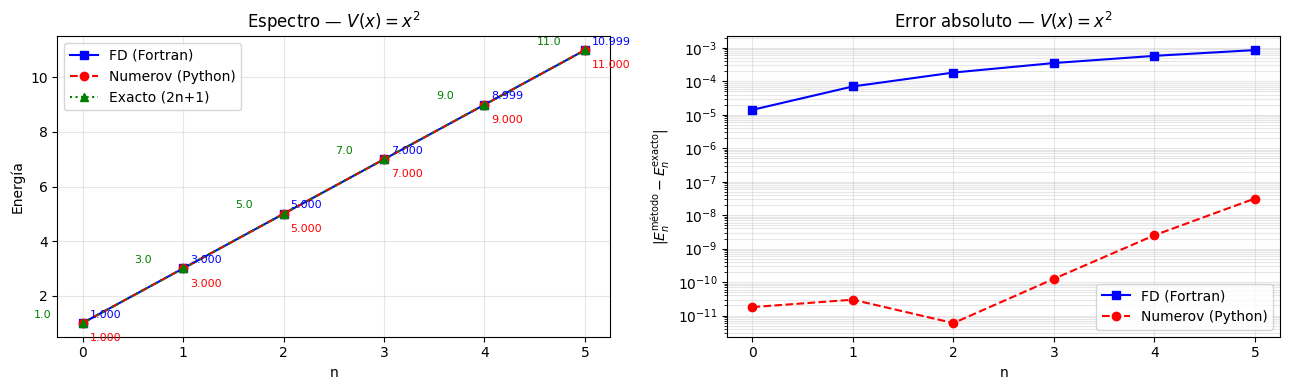

In [41]:
## 4. Espectro y error — x²

ns_x2 = np.arange(N_lev_x2)
err_fd_x2  = np.abs(E_fd_x2[:N_lev_x2]       - E_ref_x2[:N_lev_x2])
err_num_x2 = np.abs(E_num_vals_x2[:N_lev_x2] - E_ref_x2[:N_lev_x2])

fig, (ax_s, ax_e) = plt.subplots(1, 2, figsize=(13, 4))

# Espectro
ax_s.plot(ns_x2, E_fd_x2[:N_lev_x2],       'bs-',  label='FD (Fortran)')
ax_s.plot(ns_x2, E_num_vals_x2[:N_lev_x2], 'ro--', label='Numerov (Python)')
ax_s.plot(ns_x2, E_ref_x2[:N_lev_x2],      'g^:',  label='Exacto (2n+1)')
for n in range(N_lev_x2):
    ax_s.annotate(f'{E_fd_x2[n]:.3f}',       (n, E_fd_x2[n]),       textcoords='offset points', xytext=(5,  4), fontsize=8, color='b')
    ax_s.annotate(f'{E_num_vals_x2[n]:.3f}', (n, E_num_vals_x2[n]), textcoords='offset points', xytext=(5,-13), fontsize=8, color='r')
    ax_s.annotate(f'{E_ref_x2[n]:.1f}',       (n, E_ref_x2[n]),       textcoords='offset points', xytext=(-35, 4), fontsize=8, color='g')
ax_s.set_xlabel('n'); ax_s.set_ylabel('Energía')
ax_s.set_title(r'Espectro — $V(x)=x^2$'); ax_s.legend(); ax_s.grid(True, alpha=0.3)

# Error
ax_e.semilogy(ns_x2, err_fd_x2,  'bs-',  label='FD (Fortran)')
ax_e.semilogy(ns_x2, err_num_x2, 'ro--', label='Numerov (Python)')
ax_e.set_xlabel('n'); ax_e.set_ylabel(r'$|E_n^{\rm método} - E_n^{\rm exacto}|$')
ax_e.set_title(r'Error absoluto — $V(x)=x^2$'); ax_e.legend(); ax_e.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


Método                         Mediana (ms)   Desv. std (ms)
──────────────────────────────────────────────────────────────
FD Fortran  (N = 50 → 1000)         2436.72           116.40
Numerov Python  (4000 pts)         94168.81          2257.43

Numerov es 38.6× más lento que FD  (mediana de 3 runs)


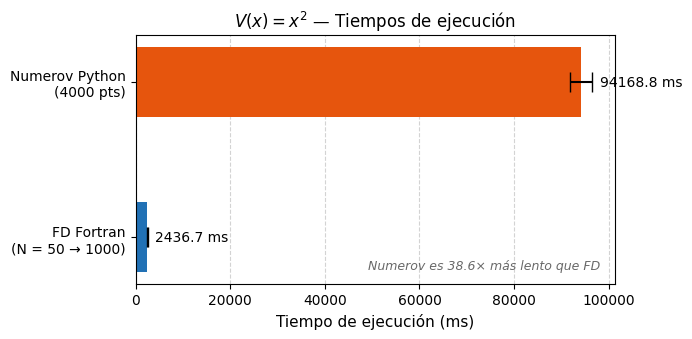

In [42]:
## 5. Tiempos de ejecución — x²

import time

N_rep_x2 = 3

t_fd_x2_runs = []
for _ in range(N_rep_x2):
    t0 = time.perf_counter()
    subprocess.run("./pot_x2_fd", shell=True, capture_output=True)
    t_fd_x2_runs.append(time.perf_counter() - t0)
t_fd_x2_med = np.median(t_fd_x2_runs) * 1e3
t_fd_x2_std = np.std(t_fd_x2_runs)    * 1e3

def _run_numerov_x2():
    pe = np.array([numerov_shoot(E, x_num_x2, V_num_x2) for E in E_scan_x2])
    found = 0
    for i in range(len(pe) - 1):
        if pe[i] * pe[i+1] < 0:
            biseccion(E_scan_x2[i], E_scan_x2[i+1], x_num_x2, V_num_x2)
            found += 1
            if found == 6: break

t_num_x2_runs = []
for _ in range(N_rep_x2):
    t0 = time.perf_counter()
    _run_numerov_x2()
    t_num_x2_runs.append(time.perf_counter() - t0)
t_num_x2_med = np.median(t_num_x2_runs) * 1e3
t_num_x2_std = np.std(t_num_x2_runs)    * 1e3

factor_x2 = t_num_x2_med / t_fd_x2_med
cmp_str_x2 = f"Numerov es {factor_x2:.1f}× {'más lento' if factor_x2 > 1 else 'más rápido'} que FD"

print(f"{'Método':<28} {'Mediana (ms)':>14} {'Desv. std (ms)':>16}")
print("─" * 62)
print(f"{'FD Fortran  (N = 50 → 1000)':<28} {t_fd_x2_med:>14.2f} {t_fd_x2_std:>16.2f}")
print(f"{'Numerov Python  (4000 pts)':<28} {t_num_x2_med:>14.2f} {t_num_x2_std:>16.2f}")
print(f"\n{cmp_str_x2}  (mediana de {N_rep_x2} runs)")

labels_x2 = ["FD Fortran\n(N = 50 → 1000)", "Numerov Python\n(4000 pts)"]
t_meds_x2 = [t_fd_x2_med, t_num_x2_med]
t_stds_x2 = [t_fd_x2_std, t_num_x2_std]
colors_x2 = ["#2171b5", "#e6550d"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels_x2, t_meds_x2, xerr=t_stds_x2, color=colors_x2, height=0.45,
               error_kw=dict(ecolor="black", lw=1.5, capsize=7), zorder=2)
ax.set_xlabel("Tiempo de ejecución (ms)", fontsize=11)
ax.set_title(r"$V(x) = x^2$ — Tiempos de ejecución", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.55, zorder=1)
offset = max(t_stds_x2) * 0.3 + max(t_meds_x2) * 0.01
for bar, t, s in zip(bars, t_meds_x2, t_stds_x2):
    ax.text(t + s + offset, bar.get_y() + bar.get_height() / 2,
            f"{t:.1f} ms", va="center", fontsize=10)
ax.annotate(cmp_str_x2, xy=(0.97, 0.06), xycoords="axes fraction",
            ha="right", fontsize=9, color="dimgray", style="italic")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


# Potencial $V(x) = |x|$ — Numerov vs Diferencias Finitas

Se resuelve la ecuación de Schrödinger estacionaria en unidades naturales ($\hbar^2/2m = 1$):

$$-\psi'' + |x|\,\psi = E\,\psi$$

en el dominio $[-8, 8]$ con condiciones de frontera $\psi(\pm 8) = 0$.

Los autovalores exactos se obtienen de los ceros de las funciones de Airy:
- Estados **pares**: $\text{Ai}'(-E_n) = 0 \Rightarrow E_n \approx 1.0188, 3.2482, 4.8201, \ldots$
- Estados **impares**: $\text{Ai}(-E_n) = 0 \Rightarrow E_n \approx 2.3381, 4.0880, 5.5206, \ldots$


In [43]:
## 1. Diferencias Finitas (Fortran) + Numerov — |x|

fd_src_abs = fd_src.replace("xi**4", "abs(xi)") \
                   .replace("12.d0/N", "16.d0/N") \
                   .replace("-6.d0+i*h", "-8.d0+i*h") \
                   .replace("data_x4_fd", "data_abs_fd")

with open("pot_abs_fd.f90", "w") as f: f.write(fd_src_abs)

r = subprocess.run("gfortran pot_abs_fd.f90 diagotri.f90 -o pot_abs_fd -O2",
                   shell=True, capture_output=True, text=True)
print("✓ Compilado |x|" if r.returncode == 0 else f"✗ Error:\n{r.stderr}")

r = subprocess.run("./pot_abs_fd", shell=True, capture_output=True, text=True)
print(r.stdout)

with open("data_abs_fd") as f:
    header = f.readline()
E_fd_abs = np.array([float(v) for v in header.strip().lstrip("#").split()[2:8]])

data_fd_abs = np.loadtxt("data_abs_fd")
x_fd_abs    = data_fd_abs[:, 0]
psi2_fd_abs = data_fd_abs[:, 1:7]

print("Energías FD |x|:", np.round(E_fd_abs, 6))

# Numerov
x_num_abs = np.linspace(-8, 8, 4000)
V_num_abs = np.abs(x_num_abs)

E_scan_abs  = np.linspace(0.0, 8.0, 10000)
psi_end_abs = np.array([numerov_shoot(E, x_num_abs, V_num_abs) for E in E_scan_abs])

E_num_vals_abs = []
psi2_num_abs   = []

for i in range(len(E_scan_abs) - 1):
    if psi_end_abs[i] * psi_end_abs[i+1] < 0:
        E_eig = biseccion(E_scan_abs[i], E_scan_abs[i+1], x_num_abs, V_num_abs)
        psi   = numerov_wf(E_eig, x_num_abs, V_num_abs)
        E_num_vals_abs.append(E_eig)
        psi2_num_abs.append(psi**2)
        if len(E_num_vals_abs) == 6:
            break

E_num_vals_abs = np.array(E_num_vals_abs)
psi2_num_abs   = np.array(psi2_num_abs)

print("Energías Numerov |x|:", np.round(E_num_vals_abs, 6))


✓ Compilado |x|
   50      1.006698      2.328761      3.226545      4.058989      4.777275      5.467953
  100      1.015821      2.335774      3.242878      4.080798      4.809676      5.508333
  200      1.018053      2.337524      3.246874      4.086172      4.817584      5.518276
  400      1.018608      2.337962      3.247867      4.087511      4.819553      5.520783
  800      1.018747      2.338071      3.248115      4.087846      4.820046      5.521426

Energías FD |x|: [1.018747 2.338071 3.248115 4.087846 4.820046 5.521426]
Energías Numerov |x|: [1.018794 2.338107 3.248198 4.087957 4.820214 5.521663]


In [44]:
## 2. Gráfica interactiva — FD vs Numerov — |x|

def graficar_abs(n):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.plot(x_fd_abs,  psi2_fd_abs[:, n], color="royalblue",  lw=2,
             label=f"|ψ|² FD  (E = {E_fd_abs[n]:.5f})")
    ax1.plot(x_num_abs, psi2_num_abs[n],   color="darkorange", lw=2, ls="--",
             label=f"|ψ|² Numerov  (E = {E_num_vals_abs[n]:.5f})")
    ax1.set_xlabel("x", fontsize=12)
    ax1.set_ylabel(r"$|\psi_n(x)|^2$", fontsize=12)
    ax1.set_xlim(-8.5, 8.5)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.3)

    x_v = np.linspace(-8, 8, 500)
    ax2.plot(x_v, np.abs(x_v), color="gray", lw=1.5, alpha=0.5, label=r"$V(x)=|x|$")
    ax2.axhline(E_fd_abs[n],       color="royalblue", ls="--", lw=1.2,
                label=f"E FD = {E_fd_abs[n]:.5f}")
    ax2.axhline(E_num_vals_abs[n], color="darkorange", ls=":", lw=1.8,
                label=f"E Numerov = {E_num_vals_abs[n]:.5f}")
    ax2.set_ylabel(r"$V(x)$  /  Energía", color="gray", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="gray")
    ax2.set_ylim(-0.5, max(E_fd_abs[n], E_num_vals_abs[n]) * 1.6 + 1)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper center")

    plt.title(r"$V(x)=|x|$ — nivel $n=" + str(n) + r"$   |   FD vs Numerov", fontsize=12)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

N_lev_abs = min(len(E_num_vals_abs), len(E_fd_abs), 6)
slider_abs = widgets.IntSlider(value=0, min=0, max=N_lev_abs - 1, step=1,
                                description="Nivel n:", continuous_update=False,
                                style={"description_width": "80px"},
                                layout=widgets.Layout(width="380px"))
display(widgets.interactive(graficar_abs, n=slider_abs))


interactive(children=(IntSlider(value=0, continuous_update=False, description='Nivel n:', layout=Layout(width=…

In [45]:
## 3. Tabla comparativa — |x|   (valores exactos via ceros de Airy)

# Valores exactos: alternados pares (ceros de Ai') e impares (ceros de Ai)
# Airy zeros: Ai'(z)=0 en z = -1.01879, -3.24820, -4.82010, ...
#             Ai(z) =0 en z = -2.33811, -4.08795, -5.52056, ...
E_ref_abs = np.array([1.018793, 2.338107, 3.248198, 4.087950, 4.820099, 5.520560])

print(f"{'n':>3}  {'FD (Fortran)':>15}  {'Numerov (Python)':>18}  "
      f"{'Exacto (Airy)':>14}  {'Δ FD':>10}  {'Δ Numerov':>10}")
print("─" * 83)
for n in range(N_lev_abs):
    dfd  = abs(E_fd_abs[n]       - E_ref_abs[n])
    dnum = abs(E_num_vals_abs[n] - E_ref_abs[n])
    print(f"{n:>3}  {E_fd_abs[n]:>15.6f}  {E_num_vals_abs[n]:>18.6f}  "
          f"{E_ref_abs[n]:>14.6f}  {dfd:>10.2e}  {dnum:>10.2e}")


  n     FD (Fortran)    Numerov (Python)   Exacto (Airy)        Δ FD   Δ Numerov
───────────────────────────────────────────────────────────────────────────────────
  0         1.018747            1.018794        1.018793    4.62e-05    6.26e-07
  1         2.338071            2.338107        2.338107    3.60e-05    4.15e-07
  2         3.248115            3.248198        3.248198    8.28e-05    6.22e-08
  3         4.087846            4.087957        4.087950    1.04e-04    7.38e-06
  4         4.820046            4.820214        4.820099    5.26e-05    1.15e-04
  5         5.521426            5.521663        5.520560    8.66e-04    1.10e-03


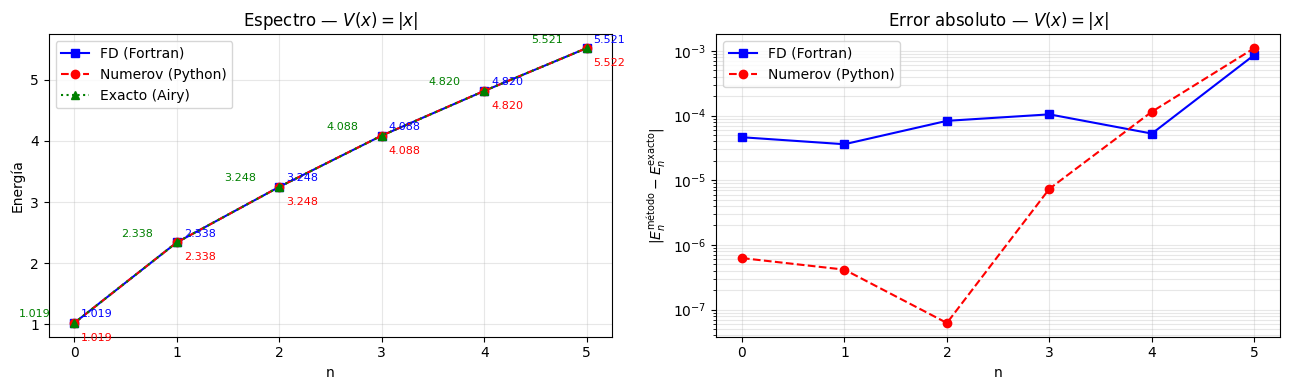

In [46]:
## 4. Espectro y error — |x|

ns_abs = np.arange(N_lev_abs)
err_fd_abs  = np.abs(E_fd_abs[:N_lev_abs]       - E_ref_abs[:N_lev_abs])
err_num_abs = np.abs(E_num_vals_abs[:N_lev_abs] - E_ref_abs[:N_lev_abs])

fig, (ax_s, ax_e) = plt.subplots(1, 2, figsize=(13, 4))

# Espectro
ax_s.plot(ns_abs, E_fd_abs[:N_lev_abs],       'bs-',  label='FD (Fortran)')
ax_s.plot(ns_abs, E_num_vals_abs[:N_lev_abs], 'ro--', label='Numerov (Python)')
ax_s.plot(ns_abs, E_ref_abs[:N_lev_abs],      'g^:',  label='Exacto (Airy)')
for n in range(N_lev_abs):
    ax_s.annotate(f'{E_fd_abs[n]:.3f}',       (n, E_fd_abs[n]),       textcoords='offset points', xytext=(5,  4), fontsize=8, color='b')
    ax_s.annotate(f'{E_num_vals_abs[n]:.3f}', (n, E_num_vals_abs[n]), textcoords='offset points', xytext=(5,-13), fontsize=8, color='r')
    ax_s.annotate(f'{E_ref_abs[n]:.3f}',       (n, E_ref_abs[n]),       textcoords='offset points', xytext=(-40, 4), fontsize=8, color='g')
ax_s.set_xlabel('n'); ax_s.set_ylabel('Energía')
ax_s.set_title(r'Espectro — $V(x)=|x|$'); ax_s.legend(); ax_s.grid(True, alpha=0.3)

# Error
ax_e.semilogy(ns_abs, err_fd_abs,  'bs-',  label='FD (Fortran)')
ax_e.semilogy(ns_abs, err_num_abs, 'ro--', label='Numerov (Python)')
ax_e.set_xlabel('n'); ax_e.set_ylabel(r'$|E_n^{\rm método} - E_n^{\rm exacto}|$')
ax_e.set_title(r'Error absoluto — $V(x)=|x|$'); ax_e.legend(); ax_e.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


Método                         Mediana (ms)   Desv. std (ms)
──────────────────────────────────────────────────────────────
FD Fortran  (N = 50 → 1000)         2473.16           131.85
Numerov Python  (4000 pts)         91508.86           269.59

Numerov es 37.0× más lento que FD  (mediana de 3 runs)


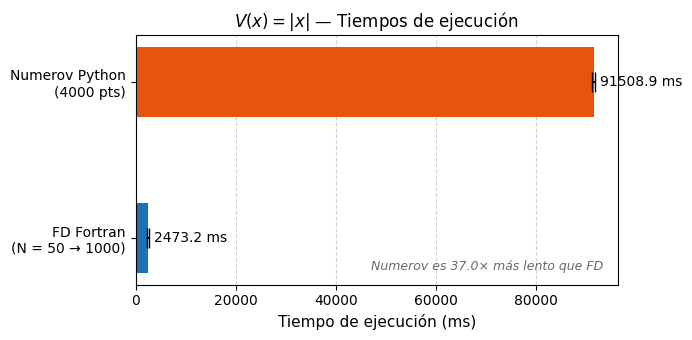

In [47]:
## 5. Tiempos de ejecución — |x|

N_rep_abs = 3

t_fd_abs_runs = []
for _ in range(N_rep_abs):
    t0 = time.perf_counter()
    subprocess.run("./pot_abs_fd", shell=True, capture_output=True)
    t_fd_abs_runs.append(time.perf_counter() - t0)
t_fd_abs_med = np.median(t_fd_abs_runs) * 1e3
t_fd_abs_std = np.std(t_fd_abs_runs)    * 1e3

def _run_numerov_abs():
    pe = np.array([numerov_shoot(E, x_num_abs, V_num_abs) for E in E_scan_abs])
    found = 0
    for i in range(len(pe) - 1):
        if pe[i] * pe[i+1] < 0:
            biseccion(E_scan_abs[i], E_scan_abs[i+1], x_num_abs, V_num_abs)
            found += 1
            if found == 6: break

t_num_abs_runs = []
for _ in range(N_rep_abs):
    t0 = time.perf_counter()
    _run_numerov_abs()
    t_num_abs_runs.append(time.perf_counter() - t0)
t_num_abs_med = np.median(t_num_abs_runs) * 1e3
t_num_abs_std = np.std(t_num_abs_runs)    * 1e3

factor_abs = t_num_abs_med / t_fd_abs_med
cmp_str_abs = f"Numerov es {factor_abs:.1f}× {'más lento' if factor_abs > 1 else 'más rápido'} que FD"

print(f"{'Método':<28} {'Mediana (ms)':>14} {'Desv. std (ms)':>16}")
print("─" * 62)
print(f"{'FD Fortran  (N = 50 → 1000)':<28} {t_fd_abs_med:>14.2f} {t_fd_abs_std:>16.2f}")
print(f"{'Numerov Python  (4000 pts)':<28} {t_num_abs_med:>14.2f} {t_num_abs_std:>16.2f}")
print(f"\n{cmp_str_abs}  (mediana de {N_rep_abs} runs)")

labels_abs = ["FD Fortran\n(N = 50 → 1000)", "Numerov Python\n(4000 pts)"]
t_meds_abs = [t_fd_abs_med, t_num_abs_med]
t_stds_abs = [t_fd_abs_std, t_num_abs_std]
colors_abs = ["#2171b5", "#e6550d"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels_abs, t_meds_abs, xerr=t_stds_abs, color=colors_abs, height=0.45,
               error_kw=dict(ecolor="black", lw=1.5, capsize=7), zorder=2)
ax.set_xlabel("Tiempo de ejecución (ms)", fontsize=11)
ax.set_title(r"$V(x) = |x|$ — Tiempos de ejecución", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.55, zorder=1)
offset = max(t_stds_abs) * 0.3 + max(t_meds_abs) * 0.01
for bar, t, s in zip(bars, t_meds_abs, t_stds_abs):
    ax.text(t + s + offset, bar.get_y() + bar.get_height() / 2,
            f"{t:.1f} ms", va="center", fontsize=10)
ax.annotate(cmp_str_abs, xy=(0.97, 0.06), xycoords="axes fraction",
            ha="right", fontsize=9, color="dimgray", style="italic")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()
